# Вариант № 21
1. Решить методом Тейлора 3-го порядка задачу Коши
$$
y'' + 4y = sin(x), \qquad y(0) = 1, \qquad y'(0) = 0, \qquad x \in [0, 2]
$$

с заданной относительной точностью 0,01.

Требуется построение графиков решения $y(x), y'(x)$, а также фазовых траекторий. 

За своевременное выполнение задания начисляется **6 баллов**.


2. Дополнительные **3 балла** будут начислены, если будет найдено точное решение и оно будет сопоставлено (построены соответствующие разностные графики) с полученным приближенным решением.

3. Еще **3 балла** будут начислены, если решение задачи Коши будет найденно с помощью встроенных функций и оно также будет сопоставлено (построены соответствующие разностные графики) с исходным приближенным решением.

Для того, чтобы лабораторная работа была засчитана требуется оформление отчета (с формулами) с описанием используемых методов в формате Jupyter notebook.

# Метод разложения в ряд Тейлора

$$
\Phi_p(t, u, h) = u'(t) + \frac{h}2 u''(t) + \cdots + \frac{h^{p - 2}}{p!} u^{(p)}(t)
$$

Для метода теретьего порядка $p = 3$
$$
\Phi_3(t, u, h) = u'(t) + \frac{h}2 u''(t) + \frac{h^2}{3!} u'''(t)
$$
$$
U'(t) = f(t, u(t)) 
$$
$$
U''(t) = f_t' + f_u'f
$$
$$
U'''(t) = f_{tt}'' + f_t' f_u' + ((f_u')^2 + 2 f_{ut}'')f + f_{uu}''f^2
$$

$$
u_{n+1} = u_n + h \Phi_3(t_n, u_n, h) \qquad \overline{0, N-1}
$$

### Применение к нашей системе

Система в форме $U' = F(x, y_1, y_2)$:

$$
F(x, y_1, y_2) = \begin{pmatrix} y_2 \\ \sin x - 4y_1 \end{pmatrix}
$$

Для каждой компоненты вычисляем производные до 3-го порядка:

**Для $y_1$:**
- $f_1 = y_2$
- $f_{1x}' = 0$
- $f_{1U}' = \begin{pmatrix} 0 & 1 \end{pmatrix}$
- $U_1' = y_2$
- $U_1'' = \sin x - 4y_1$
- $U_1''' = \cos x - 4y_2$

**Для $y_2$:**
- $f_2 = \sin x - 4y_1$
- $f_{2x}' = \cos x$
- $f_{2U}' = \begin{pmatrix} -4 & 0 \end{pmatrix}$
- $U_2' = \sin x - 4y_1$
- $U_2'' = \cos x - 4y_2$
- $U_2''' = -\sin x - 4(\sin x - 4y_1) = -5\sin x + 16y_1$

### Итоговый шаг метода

Подставляем в $\Phi_3$:

Для $y_1$:
$$
\Phi_3^{(1)} = y_2 + \frac{h}{2}(\sin x - 4y_1) + \frac{h^2}{6}(\cos x - 4y_2)
$$

Для $y_2$:
$$
\Phi_3^{(2)} = (\sin x - 4y_1) + \frac{h}{2}(\cos x - 4y_2) + \frac{h^2}{6}(-5\sin x + 16y_1)
$$

Шаг метода:
$$
y_{1,n+1} = y_{1,n} + h \cdot \Phi_3^{(1)}(x_n, y_{1,n}, y_{2,n}, h)
$$
$$
y_{2,n+1} = y_{2,n} + h \cdot \Phi_3^{(2)}(x_n, y_{1,n}, y_{2,n}, h)
$$
$$
x_{n+1} = x_n + h
$$

Нашли массив решения с помощью метода\
${U_n}^{w_N}$ - массив из N элементов решения, для сетки $ t \in w_N $ - равномерная сетка с шагом $h$

Получим $ {U_n}^{w_{2N}} $ - массив из $2N$ элементов для стки с аргументом $ t \in w_{2N} $ с шагом $h/2$

сравним m-ый элемент первого массива с 2m-ым элементом второго. Для требуемой точности $\Epsilon$ это будет иметь вид:

$$ || {U_n}^{w_{2N}}[0::2] - {U_n}^{w_N} || < \Epsilon $$

In [ ]:
import numpy as np
# from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [78]:
# Устанавливаем шрифт CMU Serif
plt.rcParams['font.family'] = 'CMU Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12

In [79]:
def Phi1(x, y1, y2, h):
    f1 = y2
    f1_p = np.sin(x) - 4 * y1
    f1_2_p = np.cos(x) - 4 * y2
    return f1 + (h / 2) * f1_p + (h**2 / 6) * f1_2_p

In [80]:
def Phi2(x, y1, y2, h):
    f2 = np.sin(x) - 4 * y1
    f2_p = np.cos(x) - 4 * y2
    f2_2_p = -5 * np.sin(x) + 16 * y1
    return f2 + (h / 2) * f2_p + (h**2 / 6) * f2_2_p

In [81]:
def Step(x, y1, y2, h):
    y1_new = y1 + h * Phi1(x, y1, y2, h)
    y2_new = y2 + h * Phi2(x, y1, y2, h)
    return y1_new, y2_new

In [82]:
def Teilor_solve_h(x0, x_end, N):
    h = (x_end - x0) / N

    X = np.linspace(x0, x_end, N + 1)
    Y1 = np.zeros(N + 1)
    Y2 = np.zeros(N + 1)

    Y1[0] = 1 # y_1(0)
    Y2[0] = 0 # y_2(0)

    for n in range(N):
        x_n = X[n]
        y1_n = Y1[n]
        y2_n = Y2[n]
        
        Y1[n+1] = y1_n + h * Phi1(x_n, y1_n, y2_n, h)
        Y2[n+1] = y2_n + h * Phi2(x_n, y1_n, y2_n, h)

    return Y1, Y2

In [83]:
def Teilor(x0, x_end, eps=0.01, N0=10, N_max=1e6):
    N = N0
    Y1_N, Y2_N = Teilor_solve_h(x0, x_end, N)

    history = []

    del_max = -1

    while N <= N_max:
        Y1_2N, Y2_2N = Teilor_solve_h(x0, x_end, 2 * N)

        Y1_2N_s = Y1_2N[0::2]
        Y2_2N_s = Y2_2N[0::2]

        del_y1 = np.max(np.abs(Y1_2N_s - Y1_N))
        del_y2 = np.max(np.abs(Y2_2N_s - Y2_N))
        del_max = max(del_y1, del_y2)

        history.append((N, del_max))

        N *= 2
        print(f'{N=}, delta = {del_max}')

        if del_max < eps:
            return Y1_2N, Y2_2N, N, history
        
        Y1_N, Y2_N = Y1_2N, Y2_2N

        
    print(f"Точность не достигнута, текущая точность: {del_max}")
    return Y1_2N, Y2_2N, N, history

In [84]:
# Параметры задачи
x0 = 0.0
x_end = 2.0

# Решение
Y1, Y2, N_final, history = Teilor(x0, x_end)

print(f"\nФинальное число шагов: {N_final}")
print(f"Финальный шаг h = {(x_end - x0)/N_final:.6f}")

N=20, delta = 0.011643014233048143
N=40, delta = 0.00174946761963235

Финальное число шагов: 40
Финальный шаг h = 0.050000


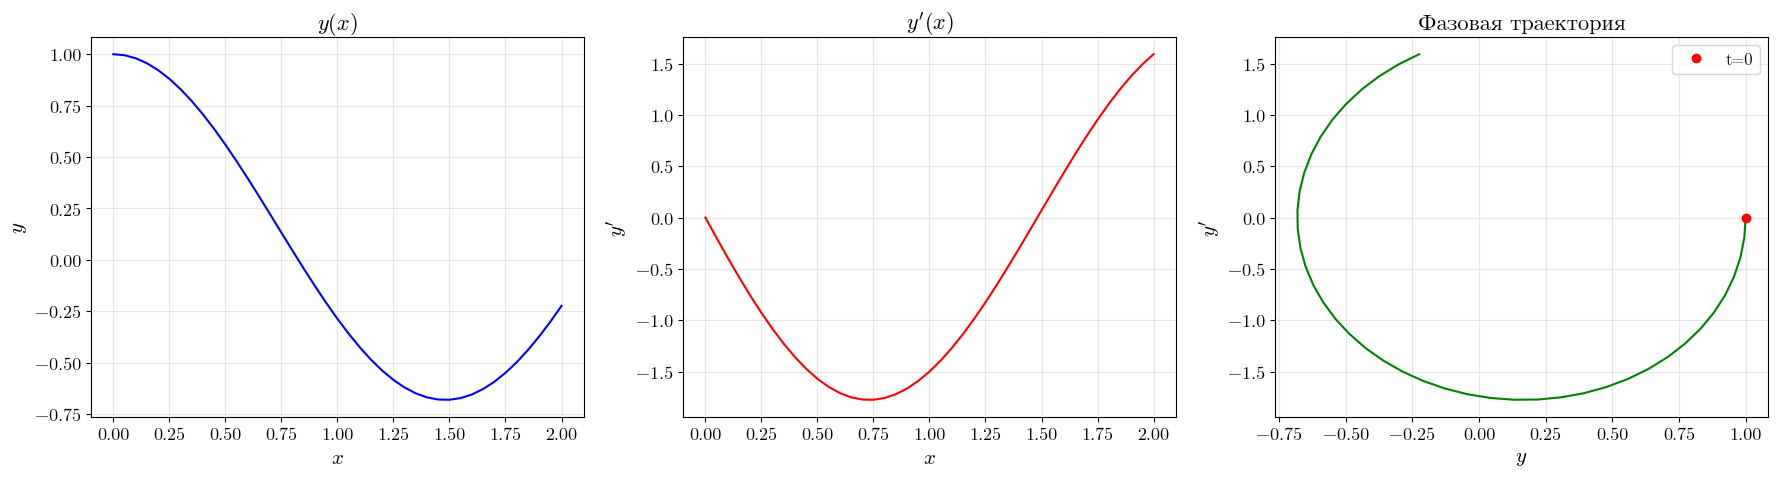

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X = np.linspace(x0, x_end, N_final + 1)

# График y(x)
axes[0].plot(X, Y1, 'b-', linewidth=1.5)
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].set_title(r'$y(x)$')
axes[0].grid(True, alpha=0.3)

# График y'(x)
axes[1].plot(X, Y2, 'r-', linewidth=1.5)
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r"$y'$")
axes[1].set_title(r"$y'(x)$")
axes[1].grid(True, alpha=0.3)

# Фазовая траектория y'(y)
axes[2].plot(Y1, Y2, 'g-', linewidth=1.5)
axes[2].set_xlabel(r'$y$')
axes[2].set_ylabel(r"$y'$")
axes[2].set_title("Фазовая траектория")
axes[2].grid(True, alpha=0.3)
# Отметим начальную точку
axes[2].plot(Y1[0], Y2[0], 'ro', markersize=6, label='t=0')
axes[2].legend()

plt.tight_layout()
plt.show()

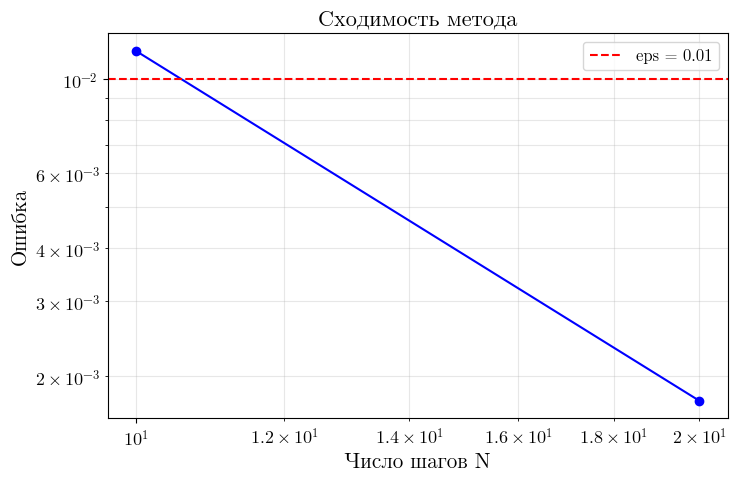

In [86]:
N_hist = [h[0] for h in history]
err_hist = [h[1] for h in history]

plt.figure(figsize=(8, 5))
plt.loglog(N_hist, err_hist, 'bo-', linewidth=1.5, markersize=6)
plt.axhline(y=0.01, color='r', linestyle='--', label=f'eps = {0.01}')
plt.xlabel('Число шагов N')
plt.ylabel('Ошибка')
plt.title('Сходимость метода')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.show()

# Доп 1
Найти точное решение и сопоставить (построены соответствующие разностные графики) с полученным приближенным решением.

## Точное решение задачи Коши

Уравнение:
$$y'' + 4y = \sin x, \quad y(0)=1,\; y'(0)=0$$

Решение соответствующего однородного уравнения
$ y'' + 4y = 0 $

Характеристическое уравнение: 

$\lambda^2 + 4 = 0 \to \lambda = \pm 2i$

$$y_{ор} = C_1 \cos 2x + C_2 \sin 2x$$

### 2. Частное решение
$ f(x) = \sin x $ Будем искать решение в виде: $y_{чр} = A\cos x + B\sin x$

$ y_{чр}' = -A \sin x + B \cos x $

$ y_{чр}'' = -A \cos x - B \sin x $

$$ -(A\cos x + B\sin x) + 4(A\cos x + B\sin x) = \sin x $$
$$ 3 A \cos x + 3 B \sin x = \sin x $$
$$ A = 0 \qquad B = \frac13$$

$$ y_{чр} = \frac13 \sin x $$

### 3. Общее решение
$$y(x) = y_{ор} + y_{чр} = C_1 \cos 2x + C_2 \sin 2x + \frac{1}{3}\sin x$$

### 4. Учёт начальных условий
- $y(0) = C_1 = 1 \to C_1 = 1$
- $y'(x) = -2C_1\sin 2x + 2C_2\cos 2x + \frac{1}{3}\cos x$
- $y'(0) = 2C_2 + \frac{1}{3} = 0 \to C_2 = -\frac{1}{6}$

### 5. Итоговое точное решение
$$y(x) = \cos 2x - \frac{1}{6}\sin 2x + \frac{1}{3}\sin x$$

$$y'(x) = -2\sin 2x - \frac{1}{3}\cos 2x + \frac{1}{3}\cos x$$

In [87]:
def y_theory(x):
    return np.cos(2*x) - (1/6)*np.sin(2*x) + (1/3)*np.sin(x)

def dy_theory(x):
    return -2*np.sin(2*x) - (1/3)*np.cos(2*x) + (1/3)*np.cos(x)

In [101]:
# Вычисляем точные значения на той же сетке
Y1_exact = y_theory(X)
Y2_exact = dy_theory(X)

# Вычисляем разности
delta_y = Y1 - Y1_exact
delta_dy= Y2 - Y2_exact

# Нормы ошибок
print(f"Максимальная ошибка по y:   {np.max(np.abs(delta_y)):.6e}")
print(f"Максимальная ошибка по y':  {np.max(np.abs(delta_dy)):.6e}")
print(f"Среднеквадратичная ошибка по y:  {np.sqrt(np.mean(delta_y**2)):.6e}")
print(f"Среднеквадратичная ошибка по y': {np.sqrt(np.mean(delta_dy**2)):.6e}")

Максимальная ошибка по y:   1.341237e-04
Максимальная ошибка по y':  2.692127e-04
Среднеквадратичная ошибка по y:  7.819139e-05
Среднеквадратичная ошибка по y': 1.155640e-04


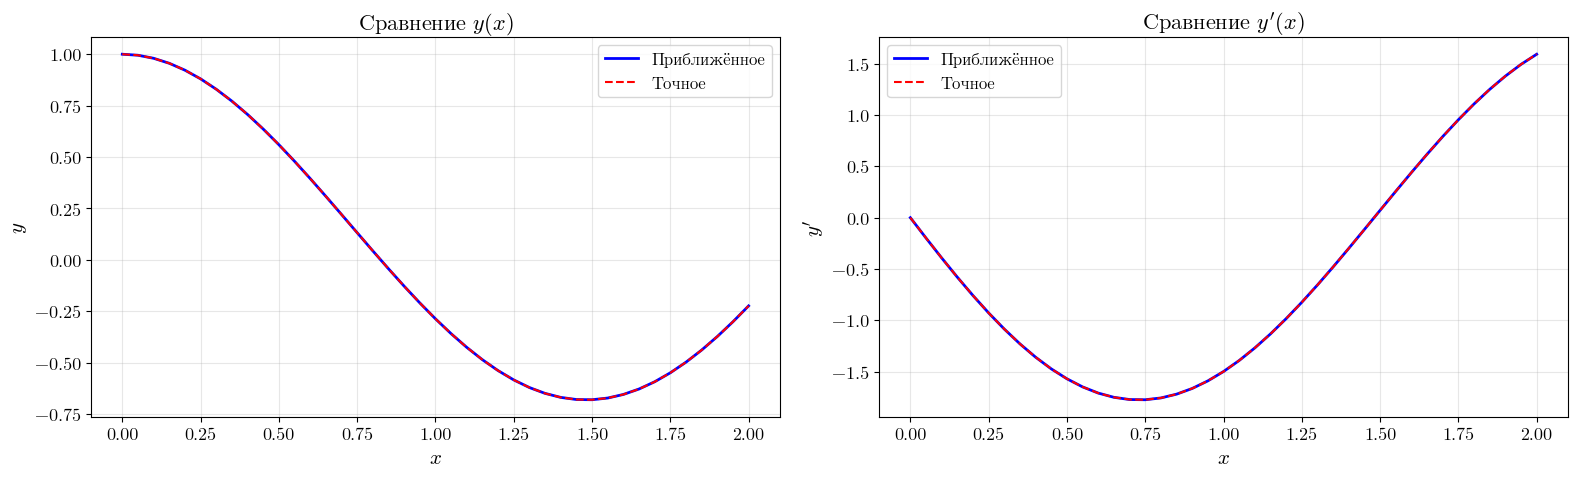

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- y(x): приближённое и точное ---
axes[0].plot(X, Y1, 'b-', linewidth=2, label='Приближённое')
axes[0].plot(X, Y1_exact, 'r--', linewidth=1.5, label='Точное')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].set_title(r'Сравнение $y(x)$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- y'(x): приближённое и точное ---
axes[1].plot(X, Y2, 'b-', linewidth=2, label="Приближённое")
axes[1].plot(X, Y2_exact, 'r--', linewidth=1.5, label='Точное')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r"$y'$")
axes[1].set_title(r"Сравнение $y'(x)$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

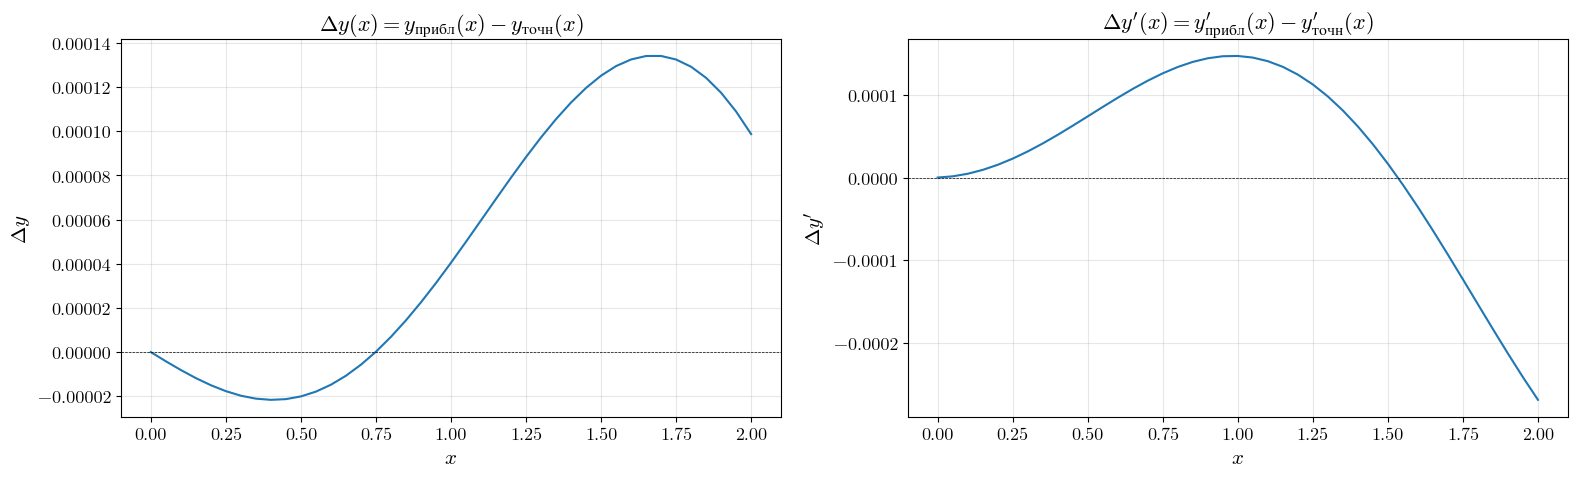

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


axes[0].plot(X, delta_y)
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r"$\Delta y$")
axes[0].set_title(r'$\Delta y(x) = y_{\text{прибл}}(x) - y_{\text{точн}}(x)$')
axes[0].grid(True, alpha=0.3)


axes[1].plot(X, delta_dy)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r"$\Delta y'$")
axes[1].set_title(r"$ \Delta y'(x) = y_{\text{прибл}}'(x) - y_{\text{точн}}'(x)$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительное задание 2

Решение задачи Коши с помощью встроенных функций и сопоставление (построены соответствующие разностные графики) с исходным приближенным решением.

In [111]:
from scipy.integrate import solve_ivp

def system_ode(x, U):
    y1, y2 = U
    return [y2, np.sin(x) - 4*y1]

sol = solve_ivp(
    system_ode,
    t_span=(0, 2),
    y0=[1.0, 0.0],
    method='RK45',
    rtol=1e-8,        
    atol=1e-10,
    max_step=0.05, # Берём из информации о самом удачном шаге(см задание 1)
    dense_output=True  
)

# Получаем значения на нашей сетке X
Y1_scipy, Y2_scipy = sol.sol(X)

In [112]:

# Вычисляем разности
delta_y = Y1 - Y1_scipy
delta_dy= Y2 - Y2_scipy

# Нормы ошибок
print(f"Максимальная ошибка по y:   {np.max(np.abs(delta_y)):.6e}")
print(f"Максимальная ошибка по y':  {np.max(np.abs(delta_dy)):.6e}")
print(f"Среднеквадратичная ошибка по y:  {np.sqrt(np.mean(delta_y**2)):.6e}")
print(f"Среднеквадратичная ошибка по y': {np.sqrt(np.mean(delta_dy**2)):.6e}")

Максимальная ошибка по y:   1.341202e-04
Максимальная ошибка по y':  2.692061e-04
Среднеквадратичная ошибка по y:  7.818929e-05
Среднеквадратичная ошибка по y': 1.155614e-04


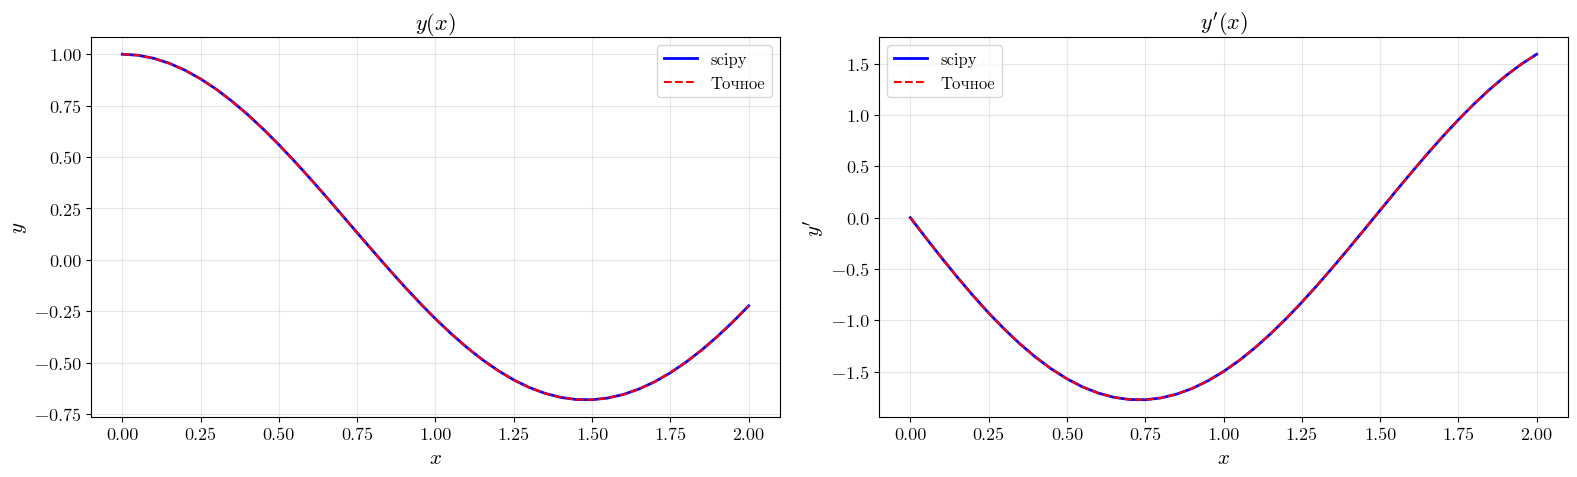

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- y(x): приближённое и точное ---
axes[0].plot(X, Y1, 'b-', linewidth=2, label='scipy')
axes[0].plot(X, Y1_scipy, 'r--', linewidth=1.5, label='Точное')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].set_title(r'$y(x)$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- y'(x): приближённое и точное ---
axes[1].plot(X, Y2, 'b-', linewidth=2, label="scipy")
axes[1].plot(X, Y2_scipy, 'r--', linewidth=1.5, label='Точное')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r"$y'$")
axes[1].set_title(r"$y'(x)$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

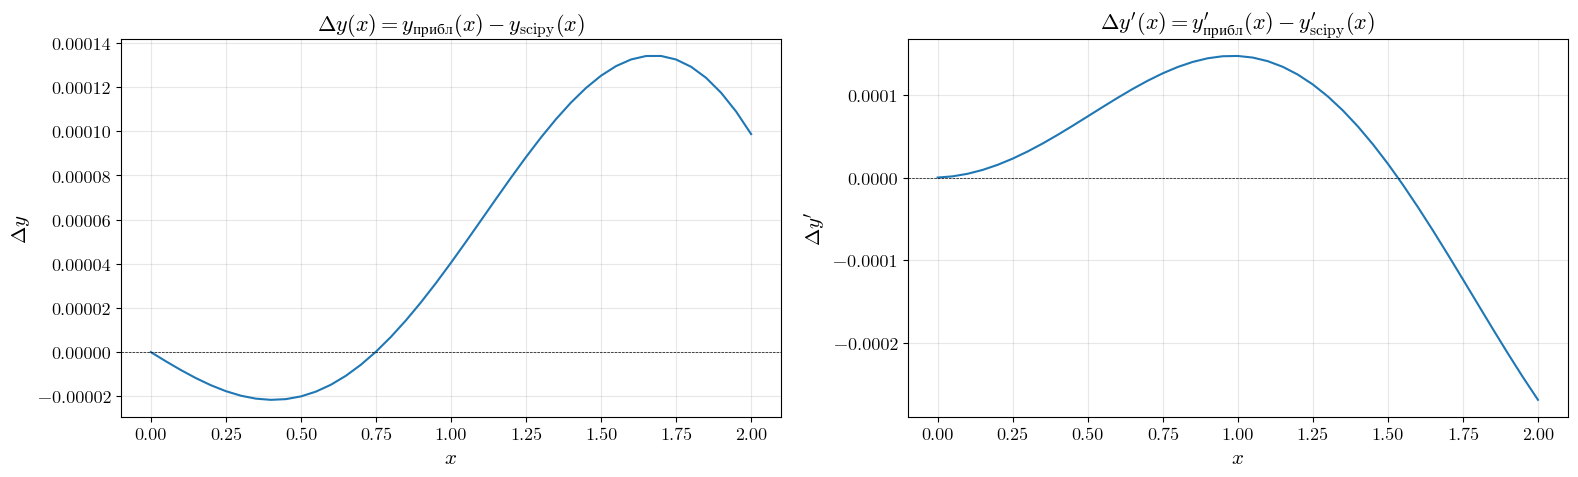

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


axes[0].plot(X, delta_y)
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r"$\Delta y$")
axes[0].set_title(r'$\Delta y(x) = y_{\text{прибл}}(x) - y_{\text{scipy}}(x)$')
axes[0].grid(True, alpha=0.3)


axes[1].plot(X, delta_dy)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r"$\Delta y'$")
axes[1].set_title(r"$ \Delta y'(x) = y_{\text{прибл}}'(x) - y_{\text{scipy}}'(x)$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()